In [201]:
from keras.datasets import mnist
from keras.utils import to_categorical
from keras import layers,models,regularizers
import numpy as np
import matplotlib.pyplot as plt

In [202]:
(train_x,train_y),(test_x,test_y) = mnist.load_data()

In [203]:
print("train_x.shape : ",train_x.shape)
print("test_x.shape : ",test_x.shape)

train_x.shape :  (60000, 28, 28)
test_x.shape :  (10000, 28, 28)


In [204]:
train_x = train_x.reshape((train_x.shape[0],28*28)).astype('float32') / 255
test_x = test_x.reshape((10000,28*28)).astype('float32') / 255

# train_x = train_x.astype('float32') / 255
# test_x = test_x.astype('float32') / 255

train_y = to_categorical(train_y)
test_y = to_categorical(test_y)

In [205]:
validation_x = train_x[50000:60000]
validation_y = train_y[50000:60000]

train_x = train_x[:50000]
train_y = train_y[:50000]

print("train_x.shape : ",train_x.shape)
print("validation_x.shape : ",validation_x.shape)
print("test_x.shape : ",test_x.shape)

train_x.shape :  (50000, 784)
validation_x.shape :  (10000, 784)
test_x.shape :  (10000, 784)


In [206]:
def buildModel(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dense(neuronNum , activation='relu') ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [207]:
def buildModelRegulalize(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , kernel_regularizer=regularizers.l2(0.001) , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dense(neuronNum , kernel_regularizer=regularizers.l2(0.001) , activation='relu') ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [208]:
def buildModelDropout(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dropout(0.5) ,
        layers.Dense(neuronNum , activation='relu') ,
        layers.Dropout(0.5) ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [209]:
history_smaller = buildModel(32, train_x).fit(train_x, train_y, epochs=20, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/20


/Users/ponlawatchangto/Desktop/VsCode/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8221 - loss: 0.6550 - val_accuracy: 0.9154 - val_loss: 0.3047
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step - accuracy: 0.9214 - loss: 0.2753 - val_accuracy: 0.9372 - val_loss: 0.2238
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - accuracy: 0.9353 - loss: 0.2248 - val_accuracy: 0.9437 - val_loss: 0.1996
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step - accuracy: 0.9435 - loss: 0.1940 - val_accuracy: 0.9501 - val_loss: 0.1783
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - accuracy: 0.9505 - loss: 0.1711 - val_accuracy: 0.9499 - val_loss: 0.1732
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - accuracy: 0.9542 - loss: 0.1545 - val_accuracy: 0.9582 - val_loss: 0.1517
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step - accuracy: 0.9583 - loss: 0.1412 - val_accuracy: 0.9530 - val_loss: 0.1577
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step - accuracy: 0.9619 - loss: 0.1295 - val_accuracy:

In [210]:
history_original = buildModel(64, train_x).fit(train_x, train_y, epochs=20, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8655 - loss: 0.5065 - val_accuracy: 0.9177 - val_loss: 0.2714
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - accuracy: 0.9348 - loss: 0.2231 - val_accuracy: 0.9428 - val_loss: 0.1953
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9495 - loss: 0.1708 - val_accuracy: 0.9579 - val_loss: 0.1510
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.9585 - loss: 0.1395 - val_accuracy: 0.9598 - val_loss: 0.1427
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step - accuracy: 0.9647 - loss: 0.1192 - val_accuracy: 0.9625 - val_loss: 0.1275
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step - accuracy: 0.9697 - loss: 0.1037 - val_accuracy: 0.9637 - val_loss: 0.1231
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - accuracy: 0.9732 - loss: 0.0913 - val_accuracy: 0.9663 - val_loss: 0.1154
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step - accuracy: 0.9758 - loss: 0.0808 - val_

In [211]:
history_larger = buildModel(512, train_x).fit(train_x, train_y, epochs=20, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9031 - loss: 0.3216 - val_accuracy: 0.9380 - val_loss: 0.2059
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9654 - loss: 0.1133 - val_accuracy: 0.9721 - val_loss: 0.0923
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9784 - loss: 0.0693 - val_accuracy: 0.9684 - val_loss: 0.1071
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9847 - loss: 0.0486 - val_accuracy: 0.9721 - val_loss: 0.0941
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9892 - loss: 0.0347 - val_accuracy: 0.9747 - val_loss: 0.0896
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9922 - loss: 0.0238 - val_accuracy: 0.9762 - val_loss: 0.0851
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9935 - loss: 0.0190 - val_accuracy: 0.9793 - val_loss: 0.0728
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9966 - loss: 0.0117 - val_accuracy: 0.

In [212]:
def plotLoss(history,name) :
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.plot(epochs,loss,'r',label='Training loss')
    plt.plot(epochs,val_loss,'b',label='Validation loss')
    plt.title('Training and Validation Loss '+ name)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [213]:
def plotAcc(history,name) :
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1 , len(accuracy) + 1)
    plt.plot(epochs,accuracy,'r',label='Training Accuracy')
    plt.plot(epochs,val_accuracy,'b',label='Validation Accuracy')
    plt.title('Training and Validation Accuracy ' + name)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

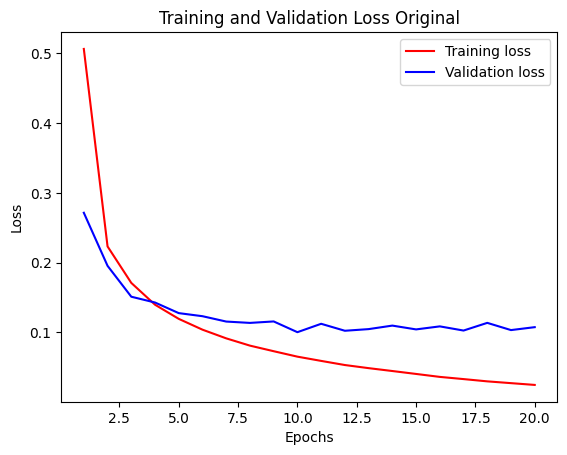

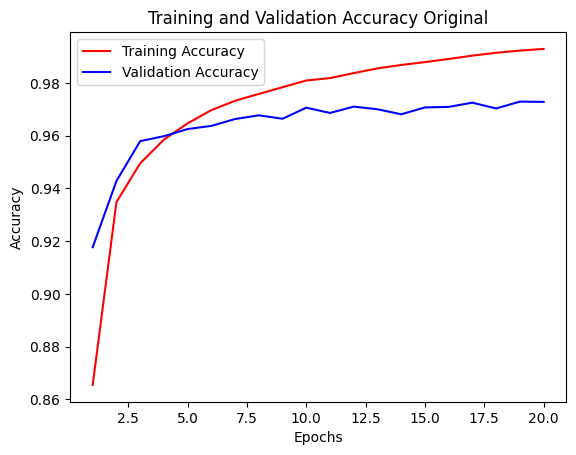

In [214]:
plotLoss(history_original,"Original")
plotAcc(history_original,"Original")

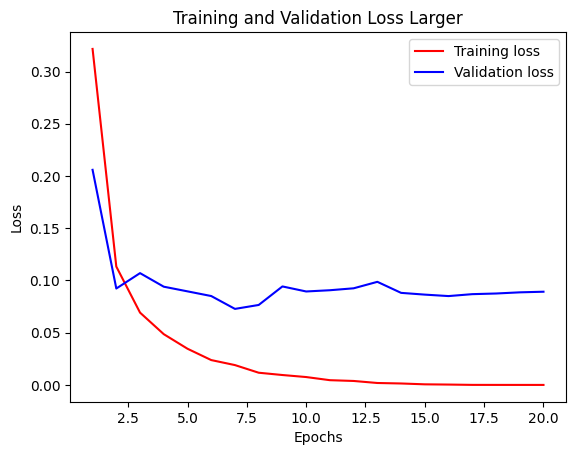

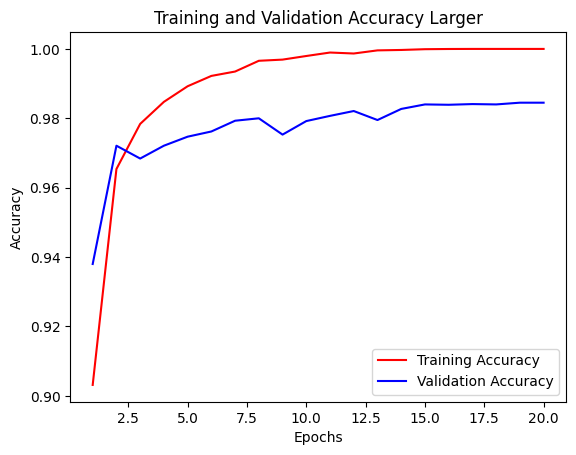

In [215]:
plotLoss(history_larger,"Larger")
plotAcc(history_larger,"Larger")

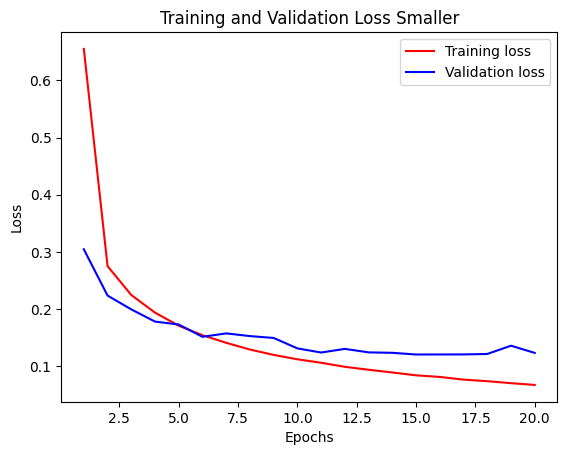

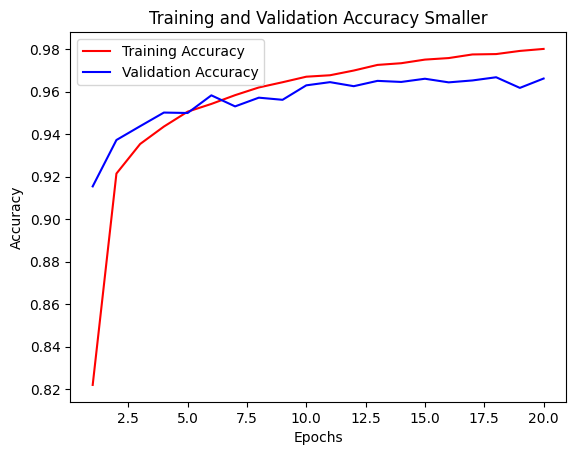

In [216]:
plotLoss(history_smaller,"Smaller")
plotAcc(history_smaller,"Smaller")

In [217]:
history_Dropout = buildModelDropout(64 , train_x).fit(train_x,train_y,epochs=20,batch_size=256,validation_data=(validation_x,validation_y))

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6476 - loss: 1.0789 - val_accuracy: 0.9103 - val_loss: 0.3242
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8335 - loss: 0.5631 - val_accuracy: 0.9268 - val_loss: 0.2517
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8668 - loss: 0.4663 - val_accuracy: 0.9360 - val_loss: 0.2237
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8790 - loss: 0.4213 - val_accuracy: 0.9439 - val_loss: 0.2005
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8919 - loss: 0.3860 - val_accuracy: 0.9503 - val_loss: 0.1847
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8984 - loss: 0.3616 - val_accuracy: 0.9521 - val_loss: 0.1771
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9014 - loss: 0.3456 - val_accuracy: 0.9537 - val_loss: 0.1724
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9060 - loss: 0.3321 - val_accuracy: 0.

In [218]:
history_Regularized = buildModelRegulalize(64 , train_x).fit(train_x,train_y,epochs=20,batch_size=256,validation_data=(validation_x,validation_y))

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8625 - loss: 0.6723 - val_accuracy: 0.9213 - val_loss: 0.4059
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - accuracy: 0.9321 - loss: 0.3704 - val_accuracy: 0.9384 - val_loss: 0.3482
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step - accuracy: 0.9444 - loss: 0.3112 - val_accuracy: 0.9549 - val_loss: 0.2824
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - accuracy: 0.9536 - loss: 0.2770 - val_accuracy: 0.9583 - val_loss: 0.2587
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - accuracy: 0.9590 - loss: 0.2516 - val_accuracy: 0.9574 - val_loss: 0.2552
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.9634 - loss: 0.2330 - val_accuracy: 0.9662 - val_loss: 0.2266
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - accuracy: 0.9650 - loss: 0.2187 - val_accuracy: 0.9671 - val_loss: 0.2161
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - accuracy: 0.9686 - loss: 0.2059 - va

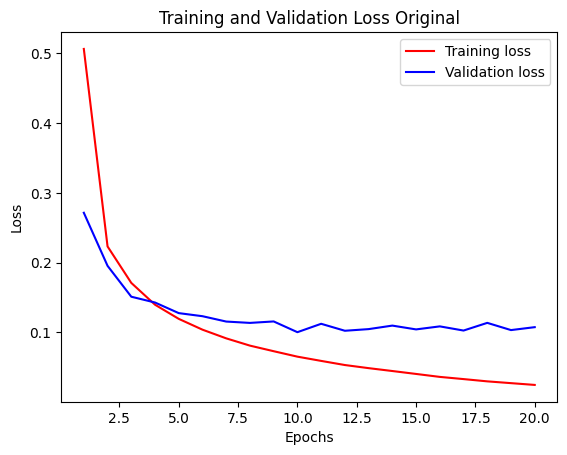

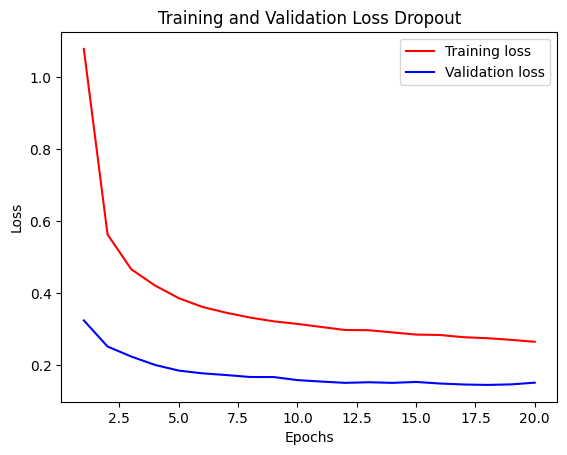

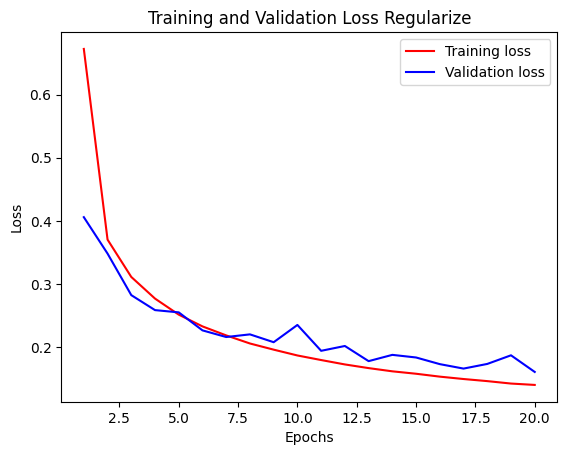

In [223]:
plotLoss(history_original,'Original')
plotLoss(history_Dropout,'Dropout')
plotLoss(history_Regularized,'Regularize')

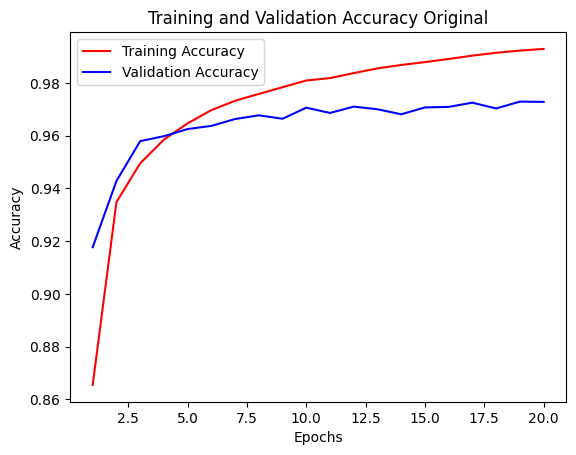

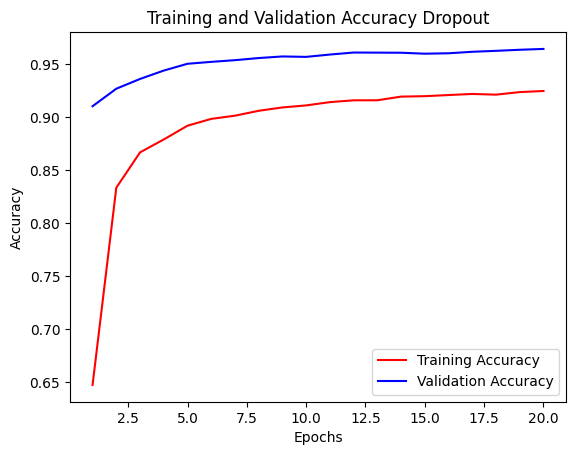

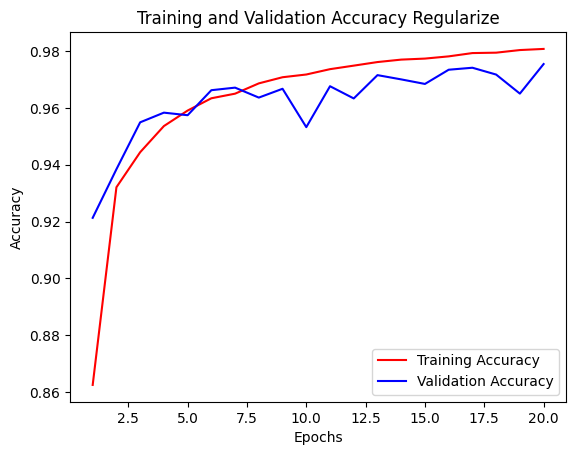

In [224]:
plotAcc(history_original,'Original')
plotAcc(history_Dropout,'Dropout')
plotAcc(history_Regularized,'Regularize')